Linear regression in pytorch testing with known parameters

In [223]:
import torch
torch.__version__

'2.12.1+cu126'

In [224]:
W_real = torch.tensor(0.6)
b_real = torch.tensor(0.9)

In [225]:
X = torch.arange(0, 100, 0.05).unsqueeze(dim=1)
X.shape

torch.Size([2000, 1])

In [226]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [227]:
!nvidia-smi

Fri Jun 26 22:47:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.43.02     CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        On  |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              3W /   50W |      70MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [228]:
W_real.to(device)
b_real.to(device)
X.to(device)

tensor([[0.0000e+00],
        [5.0000e-02],
        [1.0000e-01],
        ...,
        [9.9850e+01],
        [9.9900e+01],
        [9.9950e+01]], device='cuda:0')

In [229]:
y = X * W_real + b_real
y.shape

torch.Size([2000, 1])

In [230]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([1600, 1]),
 torch.Size([400, 1]),
 torch.Size([1600, 1]),
 torch.Size([400, 1]))

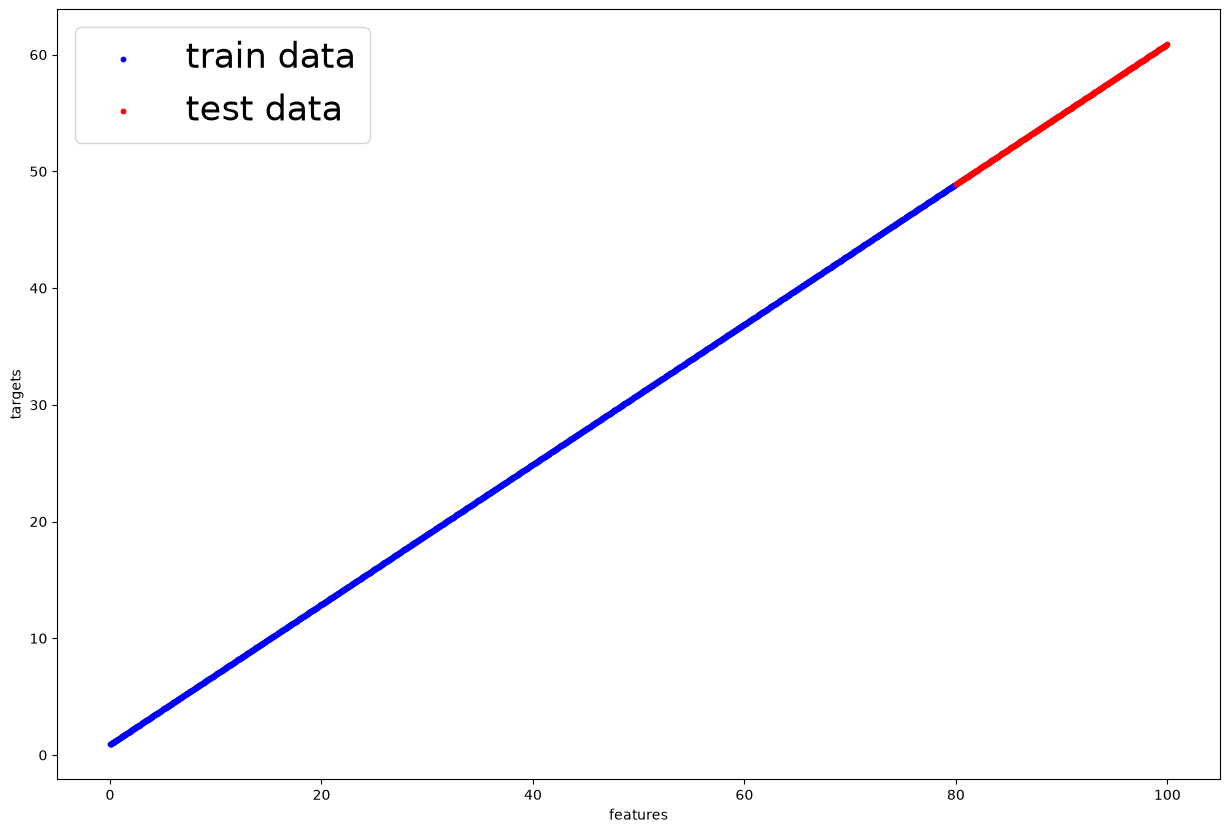

In [231]:
import matplotlib.pyplot as plt
def plot_prediction(train = X_train,
                    target = y_train,
                    test = X_test,
                    test_target = y_test,
                    pred = None):
    plt.figure(figsize=(15,10))
    plt.xlabel("features")
    plt.ylabel("targets")
    plt.scatter(train,target, c = "b", s = 10, label = 'train data')
    plt.scatter(test, test_target, c = "r", s = 10, label = 'test data')
    if pred is not None:
        plt.scatter(test, pred, c = 'g', s = 5, label = 'test prediction')
    plt.legend(prop={"size" : 25})
plot_prediction()

In [232]:
from torch import nn
class linear_regression(nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(42)
        self.linear = nn.Linear(in_features=1,out_features=1)
        
    def forward(self, x: torch.tensor) -> torch.tensor:
        return self.linear(x)


In [233]:
linear_model = linear_regression()
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.7645]], requires_grad=True),
 Parameter containing:
 tensor([0.8300], requires_grad=True)]

In [234]:
next(linear_model.parameters()).to(device)
print(type(X_train))
print(X_train.shape)
print(X_train.dtype)

<class 'torch.Tensor'>
torch.Size([1600, 1])
torch.float32


In [235]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(lr=0.01, params=linear_model.parameters())

In [236]:
def plot_loss(train_loss, test_loss, epoch_list):
    plt.figure(figsize=(15,10))
    plt.plot(train_loss, epoch_list, c = 'b', label = "Training loss")
    plt.plot(test_loss, epoch_list, c = 'r', label = "Test loss")
    plt.xlabel('loss')
    plt.ylabel('epoch')
    plt.legend(prop={"size" : 25})

In [237]:
epochs = 1200

train_loss = []
test_loss = []
epoch_list = []
test_pred = None

for epoch in range(epochs):
    
    #training
    optimizer.zero_grad()
    linear_model.train()
    y_pred = linear_model(X_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()
    
    #testing
    linear_model.eval()
    with torch.inference_mode():
        test_pred = linear_model(X_test)
        t_loss = loss_fn(test_pred, y_test)
    
    #storing loss values
    if epoch % 50 == 0:
        train_loss.append(loss.detach().numpy())
        test_loss.append(t_loss.detach().numpy())
        epoch_list.append(epoch)
        print(f"epoch :{epoch} train loss : {loss} test loss : {t_loss}")

epoch :0 train loss : 56.78559112548828 test loss : 191.91586303710938
epoch :50 train loss : 0.07952110469341278 test loss : 0.5353209972381592
epoch :100 train loss : 0.012426706962287426 test loss : 0.048018570989370346
epoch :150 train loss : 0.009207534603774548 test loss : 0.01772386021912098
epoch :200 train loss : 0.007470633834600449 test loss : 0.014840667136013508
epoch :250 train loss : 0.005872241221368313 test loss : 0.011647203005850315
epoch :300 train loss : 0.004481086507439613 test loss : 0.00888586975634098
epoch :350 train loss : 0.0033242946956306696 test loss : 0.006588375195860863
epoch :400 train loss : 0.0023999656550586224 test loss : 0.00475402781739831
epoch :450 train loss : 0.0016871329862624407 test loss : 0.0033399173989892006
epoch :500 train loss : 0.0011554249795153737 test loss : 0.0022863124031573534
epoch :550 train loss : 0.0007711283979006112 test loss : 0.00152534618973732
epoch :600 train loss : 0.0005015858914703131 test loss : 0.000991451554

In [238]:
linear_model.state_dict()

OrderedDict([('linear.weight', tensor([[0.6000]])),
             ('linear.bias', tensor([0.8988]))])

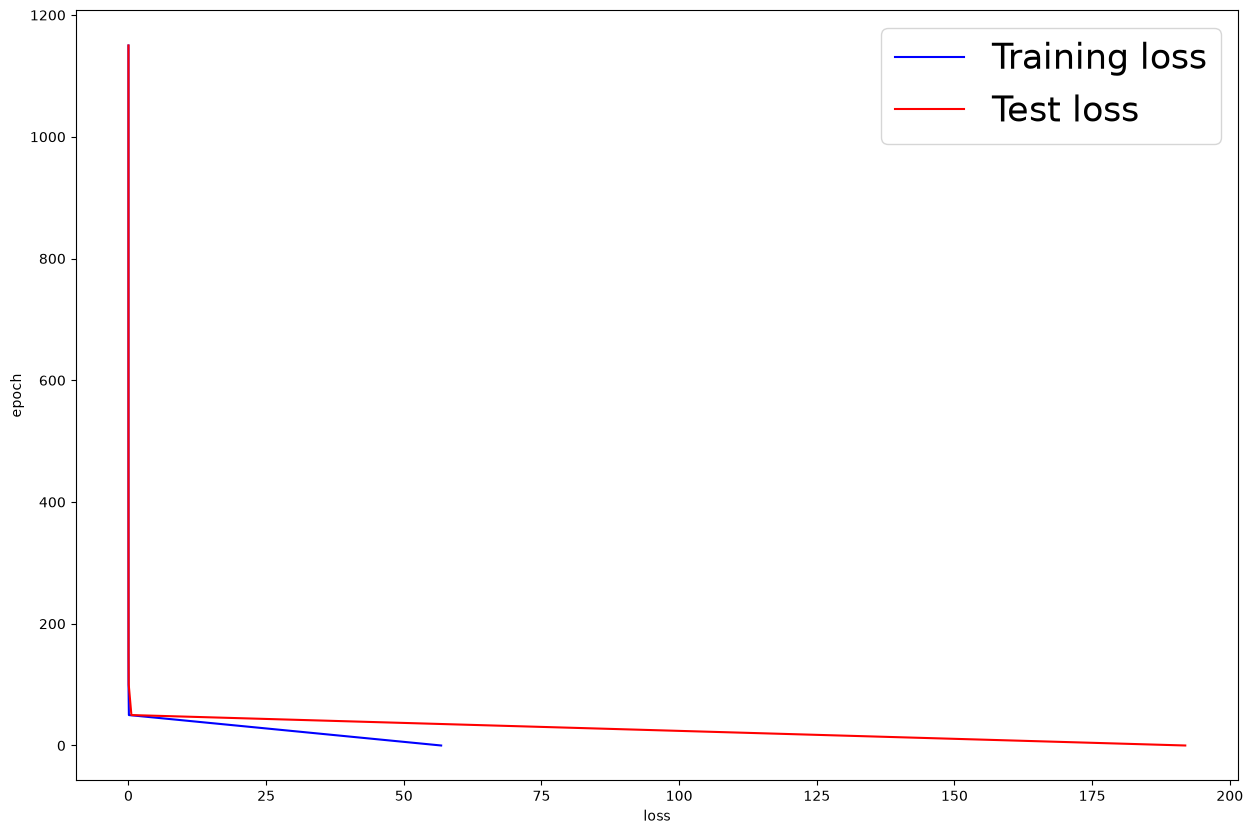

In [239]:
plot_loss(train_loss=train_loss, test_loss=test_loss, epoch_list=epoch_list)

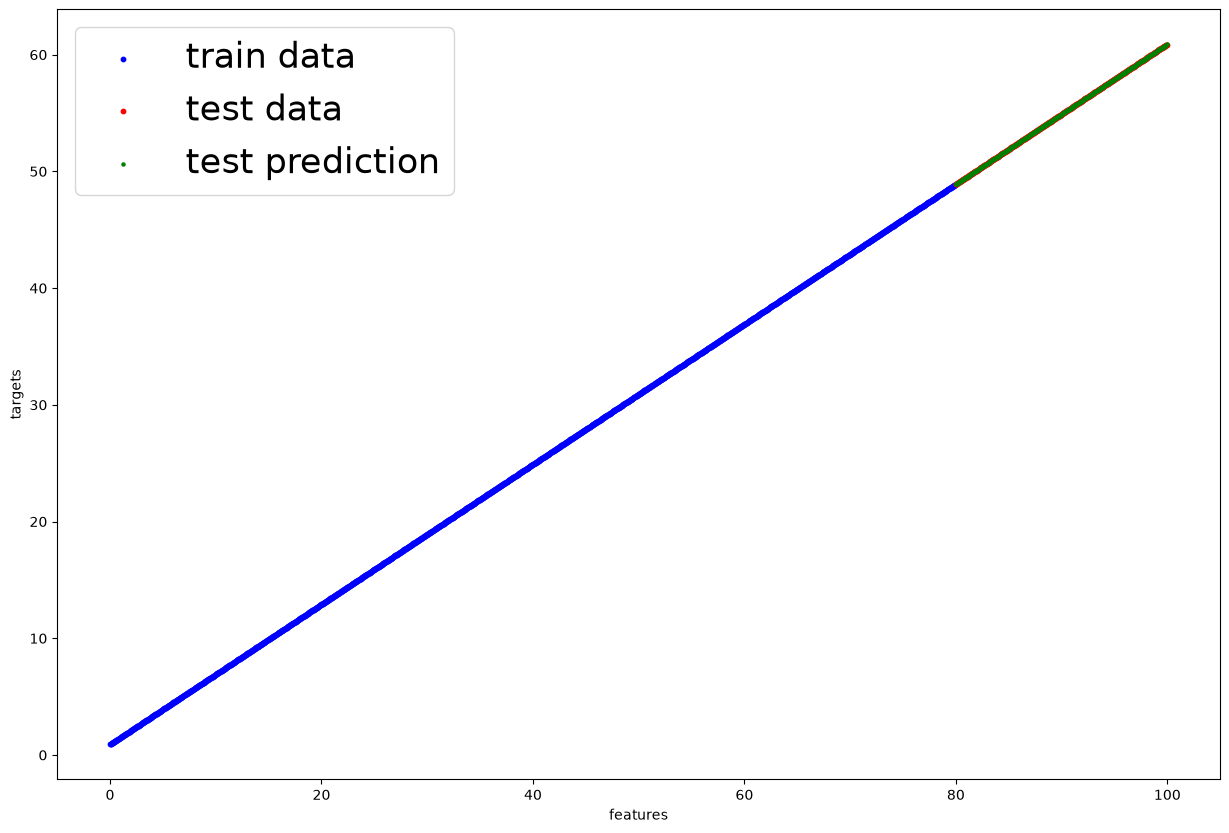

In [240]:
plot_prediction(pred=test_pred)

In [241]:
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True, parents=True)
MODEL = "Linear model.pth"
MODEL_PATH = MODEL_DIR / MODEL

torch.save(obj=linear_model.state_dict(), f=MODEL_PATH)

In [242]:
load_model = linear_regression()
load_model.load_state_dict(torch.load(f=MODEL_PATH))

<All keys matched successfully>

In [247]:
load_pred  = load_model(X_test)
(test_pred == load_pred).reshape(-1)

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr